In [1]:
ROOT_PATH = 'C:/Users/khoan/OneDrive/Documents/stock_data_scraper'
import os
os.chdir(ROOT_PATH)

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
from modules import ef_world_portfolio
from utils.constants import INDEXES_BY_COUNTRY

In [5]:
TARGET_INDEXES = {country: INDEXES_BY_COUNTRY[country] for country in ['australia', 'united_states', 'vietnam']}

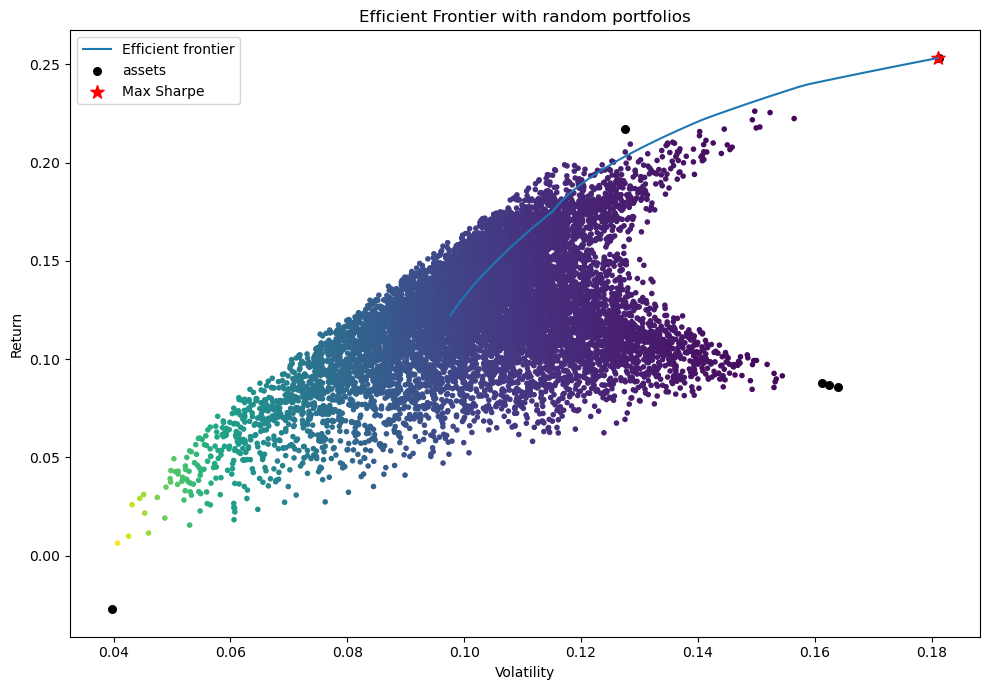

In [6]:
port, ret, std = ef_world_portfolio(
    indexes = TARGET_INDEXES, 
    return_method = 'mean_historical_return',
    portfolio_method = 'risk_based', 
    risk_threshold = 0.2,
    days = 365
)

In [7]:
prop_country = {}
for country in ['australia', 'vietnam', 'united_states']:
    per = sum([port[code] for code in INDEXES_BY_COUNTRY[country]])
    prop_country[country] = per
    print(f"[{country}] Weight: {round(per * 100, 4)}%.")
# Double the fee due to selling and buying
print(f"""Expected return: {round(ret * 100, 4)}%. 
Volatility: {round(std * 100, 4)}%.""")

[australia] Weight: 37.0796%.
[vietnam] Weight: 12.2135%.
[united_states] Weight: 50.707%.
Expected return: 22.6128%. 
Volatility: 14.9745%.


In [9]:
aus_cost = 4530.04 - 1720.7
whole_cost = aus_cost / prop_country['australia']
print("Vietnam", whole_cost * prop_country['vietnam'])
print("United states", whole_cost * prop_country['united_states'])

Vietnam 925.3544267138025
United states 3841.8239714420793


In [10]:
whole_cost

7576.518398155883